In [1]:
# Kodunuzu buraya yazın
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
# 1.1# 1.2# 1.3# 1.4
seri = pd.Series(data = [300, 150, 80, 45], index = ['Kalem','Defter','Silgi','Cetvel'])
print(seri)
print(seri['Silgi'])
print(seri.idxmin())
print(seri.sum())


Kalem     300
Defter    150
Silgi      80
Cetvel     45
dtype: int64
80
Cetvel
575


In [6]:
# 2.1# 2.2# 2.3
df = pd.DataFrame({
    'uye_adi': ['ozan', 'ömer', 'emre','ziya','yasin'],
    "paket_turu": ["Aylık", "Yıllık", "Aylık", "Yıllık", "Aylık"],
    "odenen_tutar": [155, 110, 120, 960, 365]
})
print(df.shape)
print(df.columns)

(5, 3)
Index(['uye_adi', 'paket_turu', 'odenen_tutar'], dtype='object')


In [7]:
df_csv = pd.read_csv("satislar.csv")
df_excel = pd.read_excel("rapor.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'satislar.csv'

In [11]:
df = pd.DataFrame({ "siparis_no": [1001, 1002, 1003, 1004, 1005, 1006, 1007], 
                    "kargo_suresi": [2, 5, 3, np.nan, 1, 4, 6],
                    "urun_adedi": [1, 3, 2, 5, 1, 2, 4],
                    "toplam_tutar": [150.0, 480.5, 220.0, 610.0, 90.0, 310.0, 720.0]})


In [12]:
print(df.head(3))
print(df.tail(2))
print(df.info())
print(df.describe())

   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
0        1001           2.0           1         150.0
1        1002           5.0           3         480.5
2        1003           3.0           2         220.0
   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
5        1006           4.0           2         310.0
6        1007           6.0           4         720.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   siparis_no    7 non-null      int64  
 1   kargo_suresi  6 non-null      float64
 2   urun_adedi    7 non-null      int64  
 3   toplam_tutar  7 non-null      float64
dtypes: float64(2), int64(2)
memory usage: 356.0 bytes
None
        siparis_no  kargo_suresi  urun_adedi  toplam_tutar
count     7.000000      6.000000    7.000000      7.000000
mean   1004.000000      3.500000    2.571429    368.642857
std       2.160247      1.8

In [13]:
print(df[["siparis_no", "toplam_tutar"]])
print(df.loc[0:3])
print(df.iloc[:4, -2:])

   siparis_no  toplam_tutar
0        1001         150.0
1        1002         480.5
2        1003         220.0
3        1004         610.0
4        1005          90.0
5        1006         310.0
6        1007         720.0
   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
0        1001           2.0           1         150.0
1        1002           5.0           3         480.5
2        1003           3.0           2         220.0
3        1004           NaN           5         610.0
   urun_adedi  toplam_tutar
0           1         150.0
1           3         480.5
2           2         220.0
3           5         610.0


In [14]:
print(df[df["toplam_tutar"] > 300])
print(df[(df["urun_adedi"] > 2) & (df["toplam_tutar"] > 200)])

   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
1        1002           5.0           3         480.5
3        1004           NaN           5         610.0
5        1006           4.0           2         310.0
6        1007           6.0           4         720.0
   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
1        1002           5.0           3         480.5
3        1004           NaN           5         610.0
6        1007           6.0           4         720.0


In [15]:
# 7.1# 7.2
print(df.sort_values(by="toplam_tutar", ascending=False))
print(df.sort_values(by=["urun_adedi", "kargo_suresi"]))

   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
6        1007           6.0           4         720.0
3        1004           NaN           5         610.0
1        1002           5.0           3         480.5
5        1006           4.0           2         310.0
2        1003           3.0           2         220.0
0        1001           2.0           1         150.0
4        1005           1.0           1          90.0
   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
4        1005           1.0           1          90.0
0        1001           2.0           1         150.0
2        1003           3.0           2         220.0
5        1006           4.0           2         310.0
1        1002           5.0           3         480.5
6        1007           6.0           4         720.0
3        1004           NaN           5         610.0


In [16]:
# 8.1# 8.2# 8.3
print(df["kargo_suresi"].isna().sum())
df_dolu = df.fillna(df["kargo_suresi"].median())
print(df_dolu)
df_temiz = df.dropna()
print(df_temiz.shape)

1
   siparis_no  kargo_suresi  urun_adedi  toplam_tutar
0        1001           2.0           1         150.0
1        1002           5.0           3         480.5
2        1003           3.0           2         220.0
3        1004           3.5           5         610.0
4        1005           1.0           1          90.0
5        1006           4.0           2         310.0
6        1007           6.0           4         720.0
(6, 4)


In [18]:
## Bölüm 9 — Merge (Tabloları Birleştirme)Aşağıdaki iki tabloyu kullanın:
musteriler = pd.DataFrame({ "musteri_id": [1, 2, 3, 4],
                            "ad": ["Baran", "Ceylin", "Emre", "Fulya"]})

siparisler = pd.DataFrame({"musteri_id": [1, 2, 5], 
                            "urun": ["Kulaklık", "Şarj Kablosu", "Powerbank"], 
                            "tutar": [450, 90, 320]})
birleştirme = pd.merge(musteriler, siparisler, on="musteri_id")

In [19]:
birleştirme = pd.merge(musteriler, siparisler, on="musteri_id", how="inner")
print(birleştirme)

   musteri_id      ad          urun  tutar
0           1   Baran      Kulaklık    450
1           2  Ceylin  Şarj Kablosu     90


In [20]:
# 10.1# 10.2
hafta1 = pd.DataFrame({"gun":["Pzt","Sal"], "adet":[20,35]})
hafta2 = pd.DataFrame({"gun":["Çar","Per"], "adet":[28,40]})

In [21]:
df_calisan = pd.DataFrame({"sube": ["Kadıköy", "Beşiktaş", "Kadıköy", "Şişli", "Beşiktaş"],  
                           "ad": ["Baran", "Ceylin", "Emre", "Fulya", "Gökhan"], 
                           "satis": [12000, 18500, 9500, 21000, 16000]})
tp_satis = df_calisan.groupby("sube")["satis"].sum()
print(tp_satis)

sube
Beşiktaş    34500
Kadıköy     21500
Şişli       21000
Name: satis, dtype: int64


In [22]:
# 11.1# 11.2# 11.3
print(df_calisan.groupby("sube")["satis"].sum())
print(df_calisan.groupby("sube")["satis"].mean())
print(df_calisan.groupby("sube")["satis"].agg(["sum","mean","count"]))

sube
Beşiktaş    34500
Kadıköy     21500
Şişli       21000
Name: satis, dtype: int64
sube
Beşiktaş    17250.0
Kadıköy     10750.0
Şişli       21000.0
Name: satis, dtype: float64
            sum     mean  count
sube                           
Beşiktaş  34500  17250.0      2
Kadıköy   21500  10750.0      2
Şişli     21000  21000.0      1


In [23]:
df_satis = pd.DataFrame({    "sehir": ["Bursa", "Adana", "Antalya", "Bursa", "Adana"],    "kategori": ["Elektronik", "Giyim", "Elektronik", "Giyim", "Elektronik"],    "satis": [5000, 3200, 4100, 2800, 3900]})
pivot_table = df_satis.pivot_table(values="satis", index="sehir", columns="kategori", aggfunc="sum", fill_value=0)
print(pivot_table)

kategori  Elektronik  Giyim
sehir                      
Adana           3900   3200
Antalya         4100      0
Bursa           5000   2800


In [24]:
# 12.1# 12.2
print(df_satis.pivot_table(values="satis", index="sehir", columns="kategori", aggfunc="sum", fill_value=0))

kategori  Elektronik  Giyim
sehir                      
Adana           3900   3200
Antalya         4100      0
Bursa           5000   2800


In [25]:
# 13.1# 13.2# 13.3
df_kullanici = pd.DataFrame({"kullanici_adi": ["baran23", "CEYLIN_K", "emre.y"]})
df_kullanici["kullanici_adi_kucuk"] = df_kullanici["kullanici_adi"].apply(str.lower)
df_kullanici["karakter_sayisi"] = df_kullanici["kullanici_adi"].apply(lambda x: len(x))
print(df_kullanici)

  kullanici_adi kullanici_adi_kucuk  karakter_sayisi
0       baran23             baran23                7
1      CEYLIN_K            ceylin_k                8
2        emre.y              emre.y                6


In [26]:
# 14.1# 14.2# 14.3
df_urun = pd.DataFrame({"urun_id":["10","11","12"], "agirlik_kg":["1.5","0.75","3.2"]})
print(df_urun.info())
df_urun["urun_id"] = df_urun["urun_id"].astype(int)
df_urun["agirlik_kg"] = df_urun["agirlik_kg"].astype(float)
print(df_urun.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   urun_id     3 non-null      object
 1   agirlik_kg  3 non-null      object
dtypes: object(2)
memory usage: 180.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   urun_id     3 non-null      int64  
 1   agirlik_kg  3 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 180.0 bytes
None


In [27]:
df_gelir = pd.DataFrame({    "ceyrek": ["Ç1", "Ç2", "Ç3", "Ç4"],    "gelir": [42000, 55000, 48000, 61000],    "gider": [30000, 38000, 33000, 40000]})
gelir = df_gelir["gelir"]
gider = df_gelir["gider"]

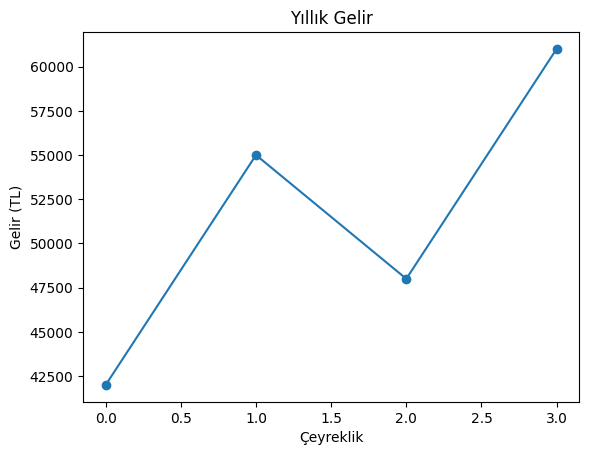

In [28]:
# 15.1# 15.2# 15.3# 15.4
import matplotlib.pyplot as plt
gelir.plot(kind="line", marker="o", title="Yıllık Gelir", xlabel="Çeyreklik", ylabel="Gelir (TL)")
plt.show()

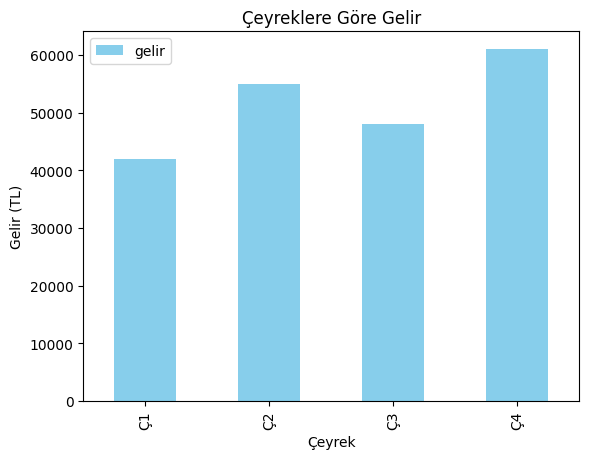

In [29]:
df_gelir.plot(
    x="ceyrek",
    y="gelir",
    kind="bar",
    color="skyblue"
)

plt.title("Çeyreklere Göre Gelir")
plt.xlabel("Çeyrek")
plt.ylabel("Gelir (TL)")
plt.show()

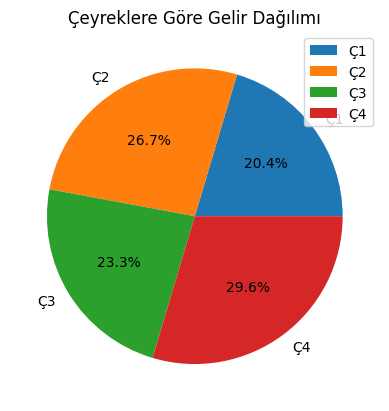

In [30]:
df_gelir.plot(
    y="gelir",
    labels=df_gelir["ceyrek"],
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Çeyreklere Göre Gelir Dağılımı")
plt.ylabel("")
plt.show()

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

df_kurs = pd.DataFrame({
    "kurs_adi": [
        "Python Programlama",
        "Web Tasarım",
        "Dijital Pazarlama",
        "Veri Bilimi",
        "Grafik Tasarım",
        "Java Programlama",
        "Sosyal Medya Pazarlama",
        "Makine Öğrenmesi"
    ],
    "kategori": [
        "Yazılım",
        "Tasarım",
        "Pazarlama",
        "Yazılım",
        "Tasarım",
        "Yazılım",
        "Pazarlama",
        "Yazılım"
    ],
    "satis_adedi": [
        85,
        45,
        70,
        95,
        35,
        60,
        55,
        80
    ]
})

print(df_kurs)

                 kurs_adi   kategori  satis_adedi
0      Python Programlama    Yazılım           85
1             Web Tasarım    Tasarım           45
2       Dijital Pazarlama  Pazarlama           70
3             Veri Bilimi    Yazılım           95
4          Grafik Tasarım    Tasarım           35
5        Java Programlama    Yazılım           60
6  Sosyal Medya Pazarlama  Pazarlama           55
7        Makine Öğrenmesi    Yazılım           80


In [32]:
toplam_satis = df_kurs.groupby("kategori")["satis_adedi"].sum()

print("Kategoriye göre toplam satış:")
print(toplam_satis)

Kategoriye göre toplam satış:
kategori
Pazarlama    125
Tasarım       80
Yazılım      320
Name: satis_adedi, dtype: int64


In [33]:
en_cok_satan = df_kurs.sort_values(
    by="satis_adedi",
    ascending=False
).head(3)

print("En çok satan 3 kurs:")
print(en_cok_satan)

En çok satan 3 kurs:
             kurs_adi kategori  satis_adedi
3         Veri Bilimi  Yazılım           95
0  Python Programlama  Yazılım           85
7    Makine Öğrenmesi  Yazılım           80


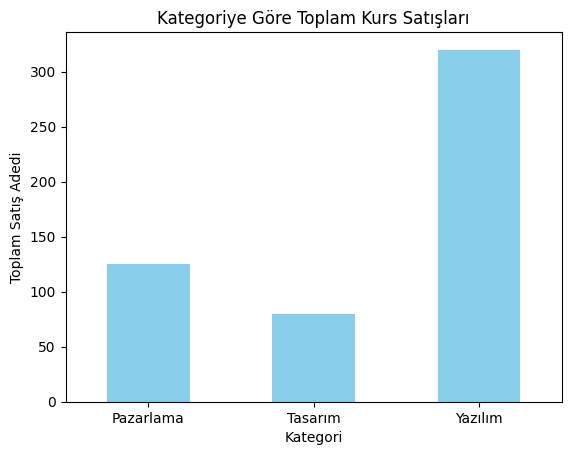

In [34]:
toplam_satis.plot(
    kind="bar",
    color="skyblue"
)

plt.title("Kategoriye Göre Toplam Kurs Satışları")
plt.xlabel("Kategori")
plt.ylabel("Toplam Satış Adedi")
plt.xticks(rotation=0)
plt.show()

In [35]:
df_kurs["durum"] = df_kurs["satis_adedi"].apply(
    lambda x: "Popüler" if x > 50 else "Standart"
)

print(df_kurs)

                 kurs_adi   kategori  satis_adedi     durum
0      Python Programlama    Yazılım           85   Popüler
1             Web Tasarım    Tasarım           45  Standart
2       Dijital Pazarlama  Pazarlama           70   Popüler
3             Veri Bilimi    Yazılım           95   Popüler
4          Grafik Tasarım    Tasarım           35  Standart
5        Java Programlama    Yazılım           60   Popüler
6  Sosyal Medya Pazarlama  Pazarlama           55   Popüler
7        Makine Öğrenmesi    Yazılım           80   Popüler
